# Zjednodušení detailu mapy doručovacích zón pro rychlé logistické dashboardy pomocí PROC GREDUCE

## Shrnutí

Regionální balíkový přepravce ukládá hranice svých obslužných území jako husté polygonové obrysy a dashboardy pro plánování tras je kvůli tomu překreslují pomalu. Tento notebook syntetizuje hraniční souřadnice pro čtyři doručovací zóny, pomocí **PROC GREDUCE** označí každý hraniční vrchol úrovní `DENSITY`, a poté vykreslí choropletovou mapu včasnosti doručení pomocí **PROC GMAP** se sníženou úrovní detailu, aby se mapa vykreslovala rychleji a přitom každá zóna zůstala rozpoznatelná.

GREDUCE zařadil 96 hraničních bodů do tří úrovní: 10 bodů na úrovni `DENSITY=0`, 44 na úrovni `DENSITY=2` a 42 na úrovni `DENSITY=3`. Ponechání pouze hrubé úrovně (`DENSITY <= 2`) sníží mapu z 96 vrcholů na 54 — tedy přibližně o 44 % — a přesto zůstávají všechny čtyři zóny na srovnání níže vedle sebe jasně rozpoznatelné.

## Zdroje dat

Všechna data se generují přímo v krocích DATA níže — bez externích souborů nebo přístupu do sítě.

| Dataset | Řádky | Klíčové proměnné | Popis |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 zóny x 24 vrcholů) | `zone` (ID), `x`, `y` | Syntetické souřadnice uzavřeného polygonového obrysu pro čtyři doručovací zóny, každá jako mírně nepravidelná elipsa vykreslená 24 vrcholy, aby redukce hustoty měla co zjednodušovat. |
| `reducedmap` | 96 | přidává `density` | Výstup PROC GREDUCE: hraniční body označené úrovní `DENSITY` (zde 0, 2 nebo 3) pro selektivní vykreslování. |
| `coarsemap` | 54 | podmnožina `reducedmap` | Podmnožina `DENSITY <= 2` — hrubá, rychle vykreslovaná úroveň použitá pro dashboardovou mapu se sníženým detailem. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Jeden řádek odezvy na zónu: syntetické procento včasného doručení a denní objem zásilek, propojené s mapou pro choropletu. |

> **Poznámka k velikosti vzorku.** Toto prostředí běží bez licence, takže každý krok DATA je omezen na 100 výstupních pozorování. Mapa je navržena na 4 zóny x 24 vrcholů = 96 bodů, aby se celé území vešlo do tohoto limitu; licencovaná instalace by vykreslila stovky vrcholů na zónu, kde se GREDUCE vyplatí ještě víc.

# Zjednodušení detailu mapy doručovacích zón pomocí PROC GREDUCE

Logističtí operátoři sledují výkonnost na mapách svých **obslužných území** — geografických zón, za které depo odpovídá. Hranice těchto zón bývají zachyceny v mapovém rozlišení: mnoho vrcholů na polygon. Když dashboard pro plánování tras překresluje několik zón najednou, veškerý tento detail vrcholů zpomaluje vykreslování, aniž by při přiblížení dashboardu přinášel jakoukoli rozhodovací hodnotu.

**PROC GREDUCE** tento problém řeší. Prochází každý polygon a označuje každý hraniční bod úrovní `DENSITY`, kde 0 označuje body definující základní tvar a vyšší úrovně označují postupně jemnější detail. Následně lze pomocí `WHERE density <= n` vybrat úroveň a vykreslit mapu se sníženým detailem, která se vykresluje rychle a přitom zůstává každá zóna rozpoznatelná.

V tomto notebooku:
1. Vygenerujeme hraniční obrysy pro čtyři doručovací zóny.
2. Spustíme PROC GREDUCE pro přiřazení úrovní `DENSITY`.
3. Prozkoumáme, jak se body rozdělují do úrovní hustoty.
4. Vykreslíme choroplety včasnosti doručení v plném a sníženém detailu a porovnáme je.

## Krok 1 — Vygenerování mapy hranic zón

Mapový dataset SAS má jedno pozorování na **hraniční vrchol**, s proměnnou `ID` pojmenovávající oblast a číselnými souřadnicemi `x`/`y`. Každou doručovací zónu vykreslíme jako mírně nepravidelnou elipsu pomocí 24 rovnoměrně rozložených úhlů, takže polygony jsou zpočátku dostatečně husté a redukce má na čem pracovat.

`call streaminit` ustaluje náhodný proud pro reprodukovatelnost a `rand('uniform')` přidává drobné nepravidelnosti do hranice, takže obrysy působí jako zaměřená území, ne jako dokonalé elipsy.

In [1]:
data zonemap;
    CALL streaminit(20260531);
    /* Ctyri dorucovaci zony, kazda jako mirne nepravidelna elipsa o 24 vrcholech.
       cx/cy = stred zony, rx/ry = nominalni polomery (velikost uzemi). */
    POLE cx[4] _temporary_ (12 32 20 40);
    POLE cy[4] _temporary_ (30 32 14 16);
    POLE rx[4] _temporary_ ( 8  9  6  7);
    POLE ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 vrcholu (0..23) na obrys */
    OPAKUJ zone = 1 TO 4;
        OPAKUJ i = 0 TO nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* radialni odchylka: priblizne +/- 6% nepravidelny okraj */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            VÝSTUP;
        KONEC;
    KONEC;
    PONECHAT zone x y;
SPUSTIT;

PROCEDURA PRŮMĚRY data=zonemap n MIN MAX nmiss;
    TŘÍDA zone;
    PROMĚNNÁ x y;
    ŠTÍTEK zone="Zóna" x="Souřadnice X" y="Souřadnice Y";
SPUSTIT;


                                                  The MEANS Procedure

                                          Analysis Variable : x Souřadnice X

        Zóna              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                          Analysis Variable : y Souřadnice Y

        Zóna              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0
  


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Tabulka PROC MEANS potvrzuje syntetickou geometrii: čtyři zóny, každá s přesně 24 hraničními body v rozumných rozsazích `x`/`y` a bez chybějících souřadnic. Čtyři elipsy zabírají nepřekrývající se oblasti (zóna 1 kolem x=12, zóna 2 kolem x=32, zóny 3 a 4 níže), takže choropleta bude čitelná jako čtyři odlišná území. Toto jsou obrysy, které PROC GREDUCE zjednoduší.

## Krok 2 — Přiřazení úrovní DENSITY pomocí PROC GREDUCE

Příkaz `ID` pojmenovává proměnnou, která definuje každou jednotkovou oblast — zde `zone`. PROC GREDUCE vyhodnocuje polygon každé zóny nezávisle (pomocí zjednodušení ve stylu Douglas-Peucker) a zapíše vstupní dataset zpět s přidanou celočíselnou proměnnou `density`: úroveň 0 označuje několik málo bodů, které ukotvují základní tvar, a vyšší úrovně označují postupně jemnější detail, který lze zahodit jako první.

Necháme GREDUCE odvodit vlastní prahové hodnoty z dat, místo abychom vynucovali pevné velikosti úrovní, a poté prozkoumáme výsledné rozdělení.

                                 Počet zachovaných hraničních bodů podle úrovně hustoty                                 

                                                   The FREQ Procedure

Hustota    Frequency    Percent
--------------------------------
0                 10     10.42
2                 44     45.83
3                 42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


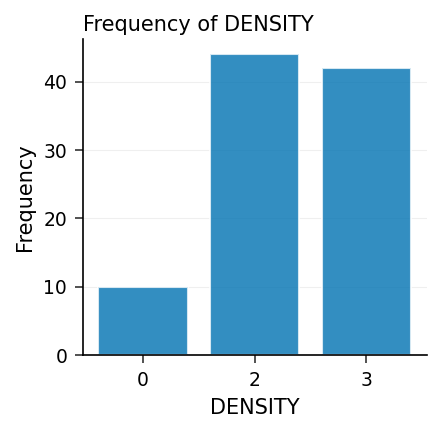

In [2]:
PROCEDURA GREDUCE data=zonemap out=reducedmap;
    id zone;
SPUSTIT;

PROCEDURA ČETNOSTI data=reducedmap;
    TABLES DENSITY / nocum;
    ŠTÍTEK DENSITY="Hustota";
    NÁZEV 'Počet zachovaných hraničních bodů podle úrovně hustoty';
SPUSTIT;


## Krok 3 — Prozkoumání úrovní hustoty

Frekvenční tabulka ukazuje, jak GREDUCE zařadil 96 hraničních bodů:

| DENSITY | Body | Podíl |
|---------|--------|-------|
| 0 | 10 | 10,4 % |
| 2 | 44 | 45,8 % |
| 3 | 42 | 43,8 % |

Pouze 10 bodů nese nejnižší úroveň (kotvy základního tvaru), zatímco zbývajících 86 se dělí mezi úrovně 2 a 3. Pro dashboardovou úroveň ponecháváme vše na `DENSITY <= 2`: tím se zachová 54 z 96 bodů a zahodí se 42 nejjemnějších (`DENSITY=3`) vrcholů. Níže uvedená PROC MEANS potvrzuje, že hrubá úroveň drží 13–14 vrcholů na zónu místo původních 24.

In [3]:
PROCEDURA PRŮMĚRY data=reducedmap n;
    TŘÍDA zone;
    KDE DENSITY <= 2;
    PROMĚNNÁ x;
    ŠTÍTEK zone="Zóna" x="Souřadnice X";
    NÁZEV 'Počet vrcholů na zónu při detailu pro dashboard (HUSTOTA <= 2)';
SPUSTIT;


                             Počet vrcholů na zónu při detailu pro dashboard (HUSTOTA <= 2)                             

                                                  The MEANS Procedure

                                          Analysis Variable : X Souřadnice X

        Zóna              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 4 — Sestavení hrubé mapy a výkonnostní odezvy na zónu

Dashboardovou úroveň materializujeme jako `coarsemap` (`DENSITY <= 2`), aby PROC GMAP mohla vykreslit zjednodušený obrys přímo. Zároveň vygenerujeme jeden řádek KPI na zónu — **podíl včasného doručení** a **denní objem zásilek** — s klíčem `zone`, aby GMAP mohla obarvit každou oblast.

In [4]:
data coarsemap;
    NASTAVIT reducedmap;
    KDE DENSITY <= 2;
SPUSTIT;

data zonekpi;
    CALL streaminit(771);
    OPAKUJ zone = 1 TO 4;
        /* podil vcasnych dodavek kolem 92 %, realisticky rozptyl */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        VÝSTUP;
    KONEC;
    ŠTÍTEK zone="Zóna" ontime_rate="Podíl včasných dodávek (%)" parcels="Počet zásilek";
SPUSTIT;

PROCEDURA TISK data=zonekpi noobs ŠTÍTEK;
    NÁZEV 'Syntetická KPI doručování podle zóny';
SPUSTIT;


                                          Syntetická KPI doručování podle zóny                                          

 Zóna      Podíl včasných dodávek (%)    Počet zásilek
    1                            92.6             4704
    2                            95.6             2932
    3                            93.4             2934
    4                            94.6             2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


Čtyři syntetické podíly včasnosti se pohybují mezi 92,6 % a 95,6 %, s denním objemem zásilek zhruba od 2 500 do 4 700. Zóna 2 je nejlepší s 95,6 %; zóna 1 je nejslabší s 92,6 %. Právě tyto hodnoty kódují barevná pásma choropletové mapy.

## Krok 5 — Vykreslení choroplet v plném a sníženém detailu

Stejnou choropletu včasnosti doručení vykreslíme dvakrát: jednou z plné 96vrcholové mapy `reducedmap` a jednou z 54vrcholové mapy `coarsemap`. `MAP=` dodává hranice, `DATA=` odezvu KPI a obě sdílejí ID `zone`. Příkaz `CHORO` vyplní každou zónu podle `ontime_rate` pomocí `LEVELS=4` barevných pásem a `COUTLINE=` pro ostré hranice. Porovnání obou map ukazuje, co redukce vizuálně stojí.

                                           Plný detail: 96 hraničních vrcholů                                           




NOTE: Option TITLE changed to Plný detail: 96 hraničních vrcholů.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Podíl včasných dodávek (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.46 seconds
  cpu   0.46 seconds


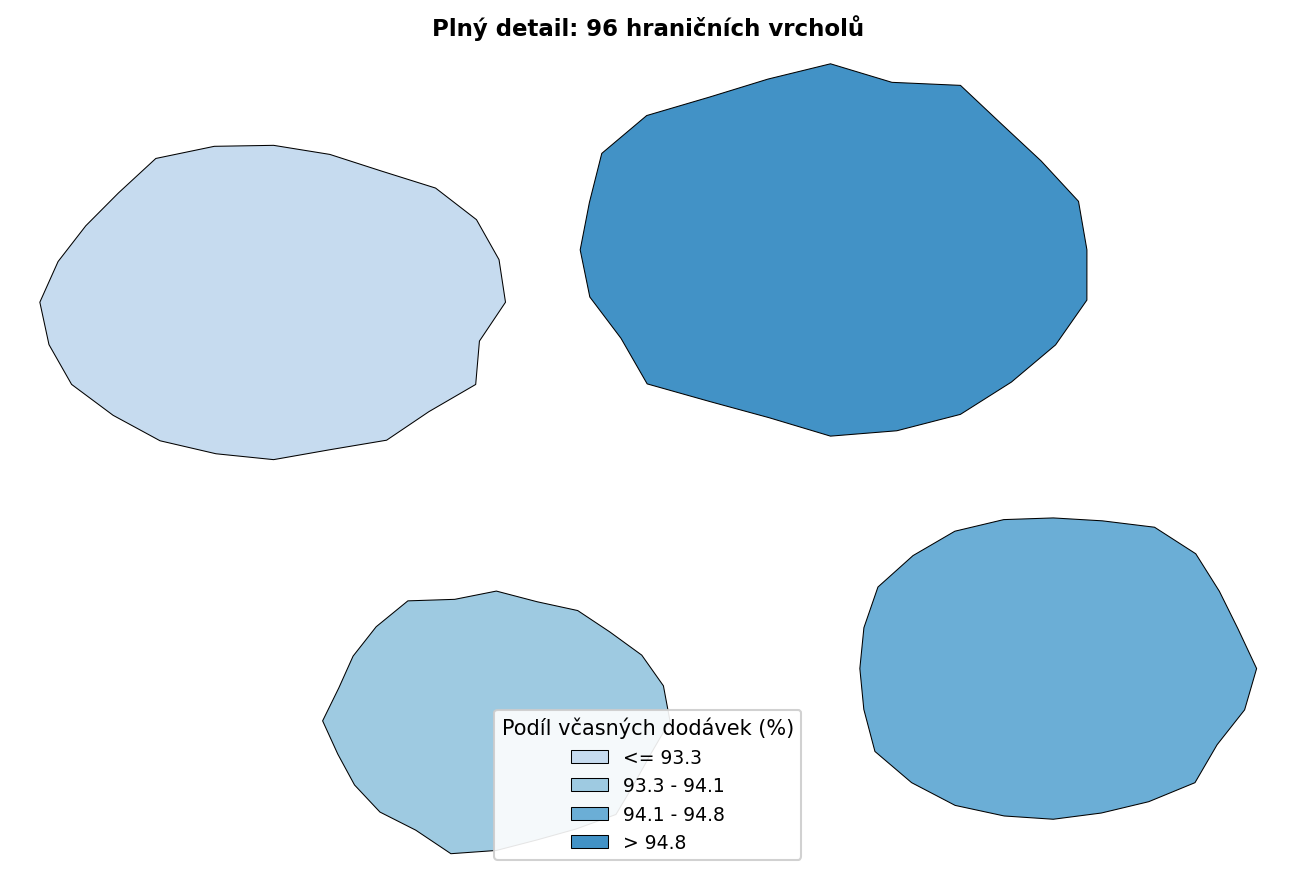

In [5]:
NÁZEV 'Plný detail: 96 hraničních vrcholů';
PROCEDURA GMAP map=reducedmap data=zonekpi;
    id zone;
    ŠTÍTEK ontime_rate="Podíl včasných dodávek (%)";
    CHORO ontime_rate / levels=4 coutline=black;
SPUSTIT;


                                       Snížený detail: 54 vrcholů (HUSTOTA <= 2)                                        




NOTE: Option TITLE changed to Snížený detail: 54 vrcholů (HUSTOTA <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Podíl včasných dodávek (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.46 seconds
  cpu   0.46 seconds


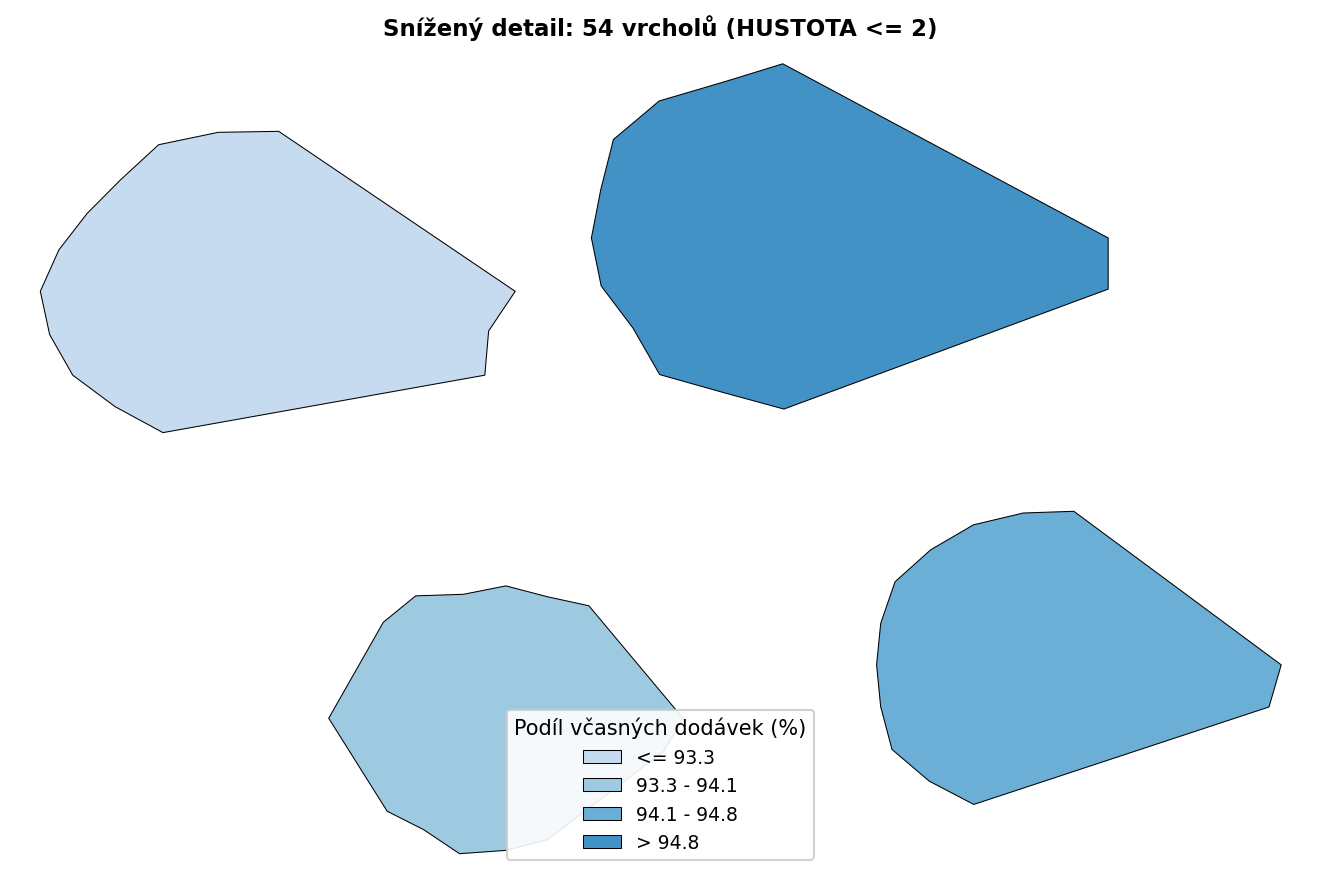

In [6]:
NÁZEV 'Snížený detail: 54 vrcholů (HUSTOTA <= 2)';
PROCEDURA GMAP map=coarsemap data=zonekpi;
    id zone;
    ŠTÍTEK ontime_rate="Podíl včasných dodávek (%)";
    CHORO ontime_rate / levels=4 coutline=black;
SPUSTIT;


## Interpretace výsledků

PROC GREDUCE převedla obrys každé 24vrcholové zóny na odstupňovanou sadu hraničních bodů (v tomto běhu úrovně 0, 2 a 3). Výběr úrovně `DENSITY <= 2` zmenšil mapu z 96 vrcholů na 54 — tedy o 44 % méně bodů, které musí vykreslovač nakreslit — a přesto obě choroplety vedle sebe potvrzují, že všechny čtyři zóny zůstávají jasně rozpoznatelné: obrysy zjednodušené mapy jsou viditelně hranatější, ale každé území si zachovává svou polohu, velikost i barevné pásmo, takže operátor čte stejný scorecard v obou případech.

Tento scorecard řadí zóny podle podílu včasného doručení: zóna 2 vede s 95,6 % (nejtmavší pásmo), zóny 3 a 4 se drží uprostřed kolem 93–95 % a zóna 1 zaostává s 92,6 % (nejsvětlejší pásmo) — právě toto území by plánovač prošetřil jako první kvůli směrování tras nebo kapacitě depa.

Protože redukce nic nedestruuje — plně detailní body zůstávají v `reducedmap` — stejný dataset podporuje jak rychlý dashboardový pohled (`DENSITY <= 2`), tak vysoce rozlišený tiskový nebo auditní pohled (`DENSITY <= 3`, nebo celou sadu) pouhou změnou jedné prahové hodnoty `WHERE`, bez nutnosti geometrii znovu importovat nebo znovu redukovat.